# Score Differences

Where there any conversations where Maverick scored higher than o3?

In [6]:
import json
from pathlib import Path

import polars as pl
import seaborn as sns
from pydantic import BaseModel

from simple_evals.improvement.models.results import AllResults, RubricItem
from simple_evals.improvement.models.rag_logs import RAGLog
from simple_evals.improvement.paths import RESULTS_DIR
from simple_evals.improvement.readers import (
    EvalInputReader,
    get_alexandria_document_by_case_id,
    RagLogReader,
    ExampleLevelMetadataReader,
)

In [7]:
baseline_results_path = RESULTS_DIR / (
    "5df4ba309cb03369f6663786ae6a9904385524a9/"
    + "maverick/healthbench_llama-4-maverick_20251023_212754_allresults.json"
)
baseline_results = AllResults.from_file(baseline_results_path)


In [ ]:
o3_run_dir = RESULTS_DIR / "9252fc34f9bc391262e8b71138ee3b86e7d0ad7a/o3"
o3_results_path = o3_run_dir / "healthbench_o3_20251029_151631_allresults.json"
o3_results = AllResults.from_file(o3_results_path)

In [9]:
def flatten_metadata(results: AllResults, model_name: str) -> list[dict]:
    """
    Flattens the 'example_level_metadata' objects from the benchmark results file.
    """
    out = []
    for metadata in results.metadata.example_level_metadata:
        out.append(
            {
                "prompt_id": metadata.prompt_id,
                f"score_{model_name}": metadata.score,
            }
        )
    return out


def flatten_rag_logs(rag_logs: list[RAGLog]) -> list[dict]:
    """
    Flattens the rag_logs into dictionaries. It does this by leaving off the
    "conversations" key.
    """
    out = []
    for log in rag_logs:
        out.append(
            {
                "prompt_id": log.prompt_id,
                "vector_search_row_id": log.vector_search_row_id,
                "atropos_case_id": log.atropos_case_id,
                "similarity_score": log.similarity_score,
            }
        )
    return out

In [10]:
baseline = pl.DataFrame(flatten_metadata(baseline_results, "baseline"))
rag = pl.DataFrame(flatten_metadata(rag_results, "rag"))
rag_logs_df = pl.DataFrame(flatten_rag_logs(rag_logs))

In [11]:
combined = baseline.join(rag, on="prompt_id").join(rag_logs_df, on="prompt_id")
combined.head()

prompt_id,score_baseline,score_rag,vector_search_row_id,atropos_case_id,similarity_score
str,f64,f64,f64,str,f64
"""5ddbc2ae-a934-4aae-9631-45bac4…",0.583333,0.583333,9067.0,"""a7cade3239274a8d8cf9718c94f27f…",0.001871
"""9cdbd221-5495-4c79-a10a-f520a5…",-0.101695,-0.101695,7811.0,"""d347b503edc34ee8a6fff5f6a48f66…",0.001998
"""d5972228-1f8d-4f01-9ac0-548c5a…",0.303371,0.202247,2935.0,"""5650e71ea6db44368a377004ae9a58…",0.002235
"""681cc590-e662-432a-aa0d-b0e8a1…",0.017857,-0.053571,1275.0,"""7716f9896468440a98d5650f136fc6…",0.001632
"""108fa967-dd8f-4d93-905e-751d95…",1.0,1.0,43.0,"""2d96c9a70cc44f729510abece9c59c…",0.001594


In [12]:
sns.set_style("whitegrid")

In [13]:
diffs = combined.with_columns(
    # Calculate the difference between the runs for each question
    (pl.col("score_rag") - pl.col("score_baseline")).alias("effect_of_rag"),
    # Calculate the difference between the runs for each question
    (
        pl.when((pl.col("score_rag") - pl.col("score_baseline") > 0))
        .then(pl.lit("better"))
        .otherwise(pl.lit("worse"))
    ).alias("better_or_worse"),
)

In [14]:
diffs.select(pl.col("better_or_worse").value_counts()).unnest("better_or_worse")

better_or_worse,count
str,u32
"""worse""",3479
"""better""",1521


(-1.2, 1.2)

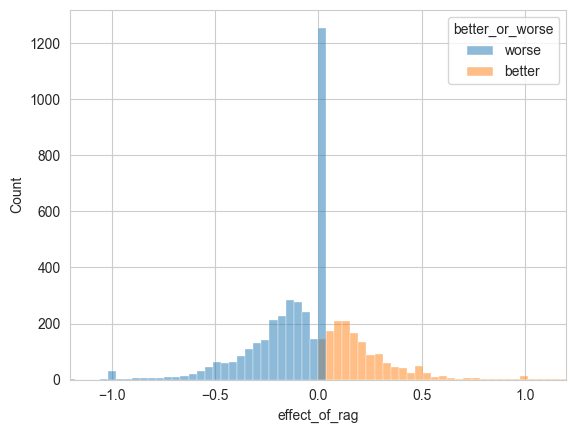

In [15]:
g = sns.histplot(diffs, x="effect_of_rag", hue="better_or_worse")
g.set_xlim(-1.2, 1.2)

(-1.2, 1.2)

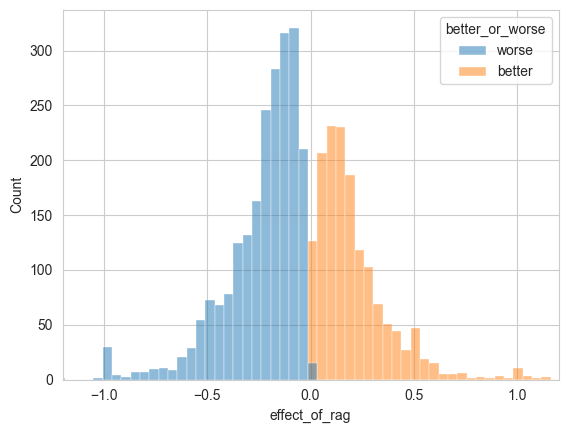

In [16]:
g = sns.histplot(
    diffs.filter(pl.col("effect_of_rag") != 0), x="effect_of_rag", hue="better_or_worse"
)
g.set_xlim(-1.2, 1.2)

Ladies and gentlemen, a bimodal distribution. I'm also seeing little bumps at -1 and 1. 

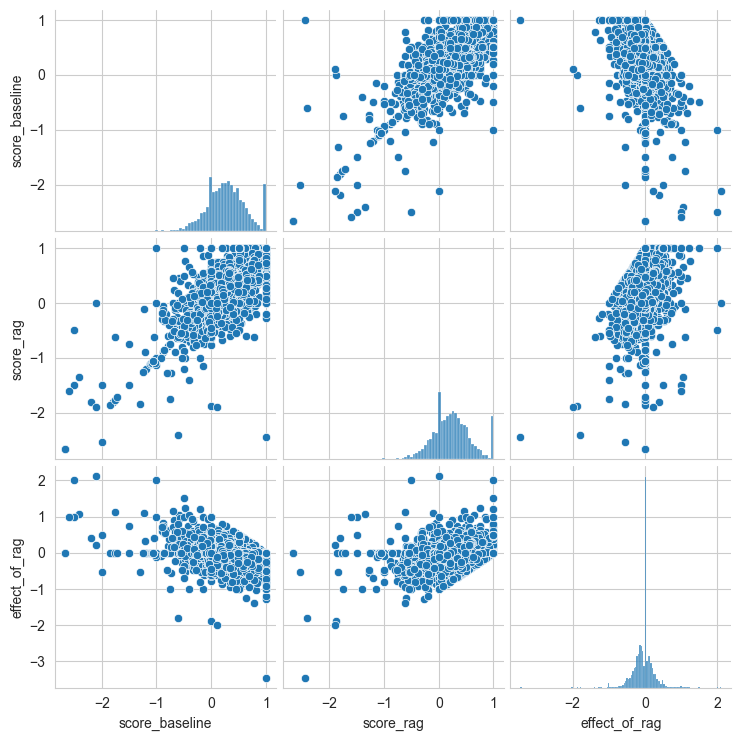

In [17]:
# What does the relationship look like between the baseline score, the rag
# score, and the difference between them?
sns.pairplot(diffs.select("score_baseline", "score_rag", "effect_of_rag").to_pandas())

Text(0, 0.5, 'Effect of Alexandria Content')

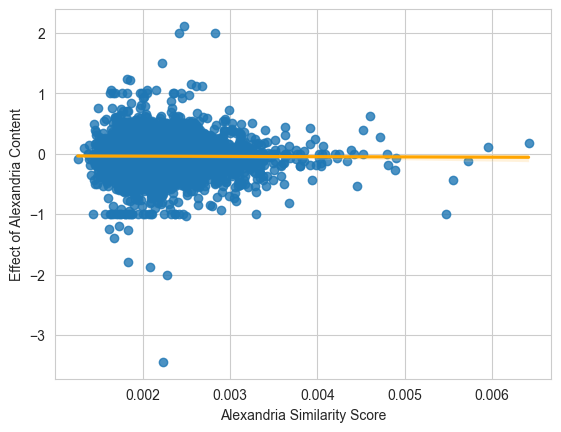

In [18]:
# Is there any relationship between the score difference and the vector similarity score?
g = sns.regplot(
    diffs, x="similarity_score", y="effect_of_rag", line_kws=dict(color="orange")
)
g.set_xlabel("Alexandria Similarity Score")
g.set_ylabel("Effect of Alexandria Content")

In [19]:
# Sample a few of the questions that improved and got worse with Alexandria content
better = diffs.filter(pl.col("effect_of_rag") > 0).sample(seed=42, n=10)
worse = diffs.filter(pl.col("effect_of_rag") < 0).sample(seed=42, n=10)

In [20]:
# os.environ["DATABRICKS_API_KEY"] = ""

In [ ]:
better_dir = Path("./sampled/rag_comparison/better")
worse_dir = Path("./sampled/rag_comparison/worse")
eval_input_reader = EvalInputReader()
rag_log_reader = RagLogReader(
    RESULTS_DIR
    / ("cbd99b81af7e1cb59d122dec8d0cb78717b8d10d/llama-4-maverick-rag2/rag_info")
)
baseline_result_metadata_reader = ExampleLevelMetadataReader(baseline_results_path)
rag_result_metadata_reader = ExampleLevelMetadataReader(rag_results_path)


class DifferingRubricItem(RubricItem):
    rag_met_criterion: bool
    rag_explanation: str


def get_criteria_that_changed(
    baseline_criteria: list[RubricItem], rag_criteria: list[RubricItem]
) -> list[DifferingRubricItem]:
    """
    Compares the two lists of rubric criteria and returns the criteria where the
    rag implementation met the criterion but the baseline implementation did
    not, and vice versa.
    """
    mismatches = []
    for baseline_criterion, rag_criterion in zip(baseline_criteria, rag_criteria):
        # I assume they will always be in the same order, but let's make sure
        assert baseline_criterion.criterion == rag_criterion.criterion
        if (baseline_criterion.criteria_met and not rag_criterion.criteria_met) or (
            not baseline_criterion.criteria_met and rag_criterion.criteria_met
        ):
            mismatches.append(
                DifferingRubricItem(
                    criterion=baseline_criterion.criterion,
                    points=baseline_criterion.points,
                    tags=baseline_criterion.tags,
                    criteria_met=baseline_criterion.criteria_met,
                    explanation=baseline_criterion.explanation,
                    rag_met_criterion=rag_criterion.criteria_met,
                    rag_explanation=rag_criterion.explanation,
                )
            )
    return mismatches


def write_cases_for_review(output_dir: Path, prompt_ids: list[str]):
    """
    Writes out a set of cases to a directory for review. Includes the input
    information, the Alexandria content that was injected into the prompt, the
    criteria where the RAG implementation differed from the baseline, and the
    completions for the baseline and RAG implementations.
    """
    for prompt_id in prompt_ids:
        # Write out the input task details
        inp = eval_input_reader.get_by_prompt_id(prompt_id)
        assert inp is not None
        output_path = output_dir / f"{prompt_id}.json"
        output_path.write_text(inp.model_dump_json(indent=2))
        # Write out the case we injected into the prompt
        case_id = rag_log_reader.get_case_id_for_prompt_id(prompt_id)
        document = get_alexandria_document_by_case_id(case_id)
        assert document is not None
        with output_path.open("a") as file:
            file.write("\n\n")
            file.write(
                f"Atropos Case ID: {document.case_id}\nContent: {document.content}"
            )
        # Write out the criteria where the RAG results differed from the baseline results
        baseline_results = baseline_result_metadata_reader.by_prompt_id(prompt_id)
        rag_results = rag_result_metadata_reader.by_prompt_id(prompt_id)
        differing_criteria = get_criteria_that_changed(
            baseline_results.rubric_items, rag_results.rubric_items
        )
        differing_criteria_dicts = [c.model_dump() for c in differing_criteria]
        with output_path.open("a") as file:
            file.write("\n\n")
            file.write("Differing Criteria:\n")
            json.dump(differing_criteria_dicts, file, indent=2)
            # Write out the baseline completion
            file.write(
                f"\n****Baseline Completion****\n{baseline_results.completion[0].content}"
            )
            # Write out the RAG completion
            file.write(
                f"\n\n\n****RAG Completion****\n{rag_results.completion[0].content}"
            )


write_cases_for_review(better_dir, better["prompt_id"].to_list())
write_cases_for_review(worse_dir, worse["prompt_id"].to_list())
